### Código para preparar los datasets para que no haya leak y que esten balanceados

In [1]:
import io
import chess.pgn
import zstandard as zstd
import pandas as pd
from sklearn.model_selection import train_test_split
import contextlib
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
# --- CONFIGURACIÓN DE RUTAS ---
input_files = [
    "../data/2026_1_preproc_higher_elo.pgn.zst",
    "../data/2026_1_preproc_high_elo.pgn.zst",
    "../data/2026_1_preproc_mid_elo.pgn.zst",
    "../data/2026_1_preproc_low_elo.pgn.zst"
]

out_train = "../data/generado/noleak/train.pgn"
out_val   = "../data/generado/noleak/val.pgn"
out_test  = "../data/generado/noleak/test.pgn"

# --- CONFIGURACIÓN DE CUPOS POR ELO ---

CUPO_TRAIN_PER_BIN = 14000
CUPO_VAL_PER_BIN   = 3000
CUPO_TEST_PER_BIN  = 3000
MIN_PLIES = 51
# Diccionarios para llevar la cuenta exacta de PARTIDAS guardadas por rango de Elo
bins_elo = range(1000, 3100, 100)
bin_corte = 3100 



In [3]:
@contextlib.contextmanager
def abrir_archivo_pgn(file_path):
    if file_path.endswith(".zst"):
        with open(file_path, "rb") as compressed:
            dctx = zstd.ZstdDecompressor()
            with dctx.stream_reader(compressed) as reader:
                yield io.TextIOWrapper(reader, encoding="utf-8")
    else:
        with open(file_path, "r", encoding="utf-8") as f:
            yield f

In [4]:
def generar_partidas_texto(text_stream):
    buffer = []
    for line in text_stream:
        if line.startswith("[Event ") and buffer:
            yield "".join(buffer)
            buffer = [line]
        else:
            buffer.append(line)
    if buffer:
        yield "".join(buffer)

In [ ]:
def obtener_bin_elo(elo):
    # Redondea el elo hacia abajo a la centena más cercana
    bin_calculado = (elo // 100) * 100

    return min(bin_calculado, bin_corte)

In [6]:
print("Iniciando Pasada 1: Mapeo de Jugadores (Prevención de Data Leakage)...")
metadata = []

for file_path in input_files:
    print(f"Leyendo jugadores de: {file_path}")
    conteo = 0
    with abrir_archivo_pgn(file_path) as text_stream:
        for raw_game_str in generar_partidas_texto(text_stream):
            conteo += 1
            game_io = io.StringIO(raw_game_str)
            headers = chess.pgn.read_headers(game_io)
            
            if headers:
                try:
                    w_elo = int(headers.get("WhiteElo", 0))
                    b_elo = int(headers.get("BlackElo", 0))
                    # Solo registramos al jugador de blancas para clasificarlo
                    if w_elo >= 1000:
                        metadata.append({'Player': headers.get("White"), 'Elo': w_elo})
                    if b_elo >= 1000:
                        metadata.append({'Player': headers.get("Black"), 'Elo': b_elo})
                except:
                    pass
            
            # Un límite razonable para no leer todo si los archivos son inmensos
            if len(metadata) % 100000 == 0: 
                print(f"Se procesaron {len(metadata)/2} partidas.")  
            if conteo > 2000000: 
                break
            
df = pd.DataFrame(metadata)
player_elo = df.groupby('Player')['Elo'].mean().reset_index()
player_elo['EloBin'] = (player_elo['Elo'] // 100) * 100
player_elo.loc[player_elo['EloBin'] >= bin_corte, 'EloBin'] = bin_corte
# Separamos a los jugadores (noleak)
# Aquí no balanceamos nada, solo dividimos a la población entera 70/15/15
train_players, temp_players = train_test_split(player_elo, test_size=0.30, random_state=42)
val_players, test_players = train_test_split(temp_players, test_size=0.50, random_state=42)

train_set = set(train_players['Player'])
val_set = set(val_players['Player'])
test_set = set(test_players['Player'])

print("Pasada 1 completada.")

Iniciando Pasada 1: Mapeo de Jugadores (Prevención de Data Leakage)...
Leyendo jugadores de: ../data/2026_1_preproc_higher_elo.pgn.zst
Se procesaron 50000.0 partidas.
Se procesaron 100000.0 partidas.
Se procesaron 150000.0 partidas.
Se procesaron 200000.0 partidas.
Se procesaron 250000.0 partidas.
Se procesaron 300000.0 partidas.
Se procesaron 350000.0 partidas.
Se procesaron 400000.0 partidas.
Se procesaron 450000.0 partidas.
Se procesaron 500000.0 partidas.
Se procesaron 550000.0 partidas.
Se procesaron 600000.0 partidas.
Se procesaron 650000.0 partidas.
Se procesaron 700000.0 partidas.
Se procesaron 750000.0 partidas.
Se procesaron 800000.0 partidas.
Se procesaron 850000.0 partidas.
Se procesaron 900000.0 partidas.
Se procesaron 950000.0 partidas.
Se procesaron 1000000.0 partidas.
Se procesaron 1050000.0 partidas.
Se procesaron 1100000.0 partidas.
Se procesaron 1150000.0 partidas.
Se procesaron 1200000.0 partidas.
Leyendo jugadores de: ../data/2026_1_preproc_high_elo.pgn.zst
Se proc

In [7]:
bins_obligatorios = [b for b in bins_elo if b < bin_corte]
conteo_train = {b: 0 for b in bins_elo}
conteo_val   = {b: 0 for b in bins_elo}
conteo_test  = {b: 0 for b in bins_elo}
def cupos_estrictos_alcanzados():
    for b in bins_obligatorios:
        if conteo_train[b] < CUPO_TRAIN_PER_BIN or \
           conteo_val[b] < CUPO_VAL_PER_BIN or \
           conteo_test[b] < CUPO_TEST_PER_BIN:
            return False # Si falta al menos uno, seguimos leyendo
    return True

In [8]:
print("\nIniciando Pasada 2: Extracción de partidas por cupos estrictos...")
total_descartadas = 0
total_guardadas = 0
cupos_llenos = False
cant_maximas = [20000*7 ,20000*4,20000*8,3*20000]
with open(out_train, "w", encoding="utf-8") as f_train, \
     open(out_val, "w", encoding="utf-8") as f_val, \
     open(out_test, "w", encoding="utf-8") as f_test:

    for i in range(len(input_files)):
        file_path = input_files[i]

        if cupos_llenos: break
            
        print(f"Procesando extracciones de: {file_path}")
        agregadas_este_archivo = 0 # Contador local para el archivo actual
        with abrir_archivo_pgn(file_path) as text_stream:
            for raw_game_str in generar_partidas_texto(text_stream):
                
                # Freno de mano: si ya llenamos todos los cupos, salimos.
                if total_guardadas > 0 and total_guardadas % 5000 == 0:
                    if cupos_estrictos_alcanzados():
                                            print(f"¡Cupos obligatorios alcanzados! (salvo {bin_corte}+). Deteniendo lectura...")
                                            cupos_llenos = True
                                            break
                if agregadas_este_archivo >= cant_maximas[i]:
                    print(f"Límite de {cant_maximas[i]} alcanzado. Pasando al siguiente archivo...")
                    break

                game_io = io.StringIO(raw_game_str)
                headers = chess.pgn.read_headers(game_io)
                if headers is None:
                    total_descartadas += 1
                    continue

                w_player = headers.get("White")
                b_player = headers.get("Black")
                
                try:
                    w_elo = int(headers.get("WhiteElo", 0))
                    b_elo = int(headers.get("BlackElo", 0))
                except:
                    total_descartadas += 1
                    continue
                
                elo_bin = obtener_bin_elo((w_elo+b_elo)/2)

                if elo_bin not in bins_elo:
                    total_descartadas += 1
                    continue

                es_train = w_player in train_set and b_player in train_set
                es_val   = w_player in val_set and b_player in val_set
                es_test  = w_player in test_set and b_player in test_set

                if not (es_train or es_val or es_test):
                    total_descartadas += 1
                    continue

                #game_io.seek(0)
                #game = chess.pgn.read_game(game_io)
                
               # num_plies = game.end().ply()
                if not re.search(r'\b26\.', raw_game_str):
                    total_descartadas += 1
                    continue
                #if not (MIN_PLIES <= num_plies):
                #    total_descartadas += 1
                #   continue

                if es_train:
                    if conteo_train[elo_bin] < CUPO_TRAIN_PER_BIN:
                        f_train.write(raw_game_str)
                        conteo_train[elo_bin] += 1
                        total_guardadas += 1
                        agregadas_este_archivo += 1
                    else:
                        total_descartadas += 1
                elif es_val:
                    if conteo_val[elo_bin] < CUPO_VAL_PER_BIN:
                        f_val.write(raw_game_str)
                        conteo_val[elo_bin] += 1
                        total_guardadas += 1
                        agregadas_este_archivo += 1
                    else:
                        total_descartadas += 1
                elif es_test:
                    if conteo_test[elo_bin] < CUPO_TEST_PER_BIN:
                        f_test.write(raw_game_str)
                        conteo_test[elo_bin] += 1
                        total_guardadas += 1
                        agregadas_este_archivo += 1
                    else:
                        total_descartadas += 1

                if (total_descartadas + total_guardadas) % 10000 == 0:
                     print(f"  Guardadas {total_guardadas} partidas, descartadas {total_descartadas}...")


print("\n--- DISTRIBUCIÓN FINAL DE PARTIDAS POR ELO (Train) ---")
for b in bins_elo:
    if conteo_train[b] > 0:
        if b == 2600:
            print(f"Elo 2600+: {conteo_train[b]} partidas")
        else:
            print(f"Elo {b}-{b+99}: {conteo_train[b]} partidas")

print(f"\nTotal General Guardadas: {total_guardadas}")
print(f"Total General descartadas: {total_descartadas}")


Iniciando Pasada 2: Extracción de partidas por cupos estrictos...
Procesando extracciones de: ../data/2026_1_preproc_higher_elo.pgn.zst
  Guardadas 4631 partidas, descartadas 5369...
  Guardadas 37680 partidas, descartadas 52320...
  Guardadas 40360 partidas, descartadas 59640...
  Guardadas 43076 partidas, descartadas 66924...
  Guardadas 45884 partidas, descartadas 74116...
  Guardadas 49407 partidas, descartadas 90593...
  Guardadas 52245 partidas, descartadas 107755...
  Guardadas 61528 partidas, descartadas 158472...
  Guardadas 65867 partidas, descartadas 194133...
  Guardadas 67735 partidas, descartadas 212265...
  Guardadas 70658 partidas, descartadas 239342...
  Guardadas 72243 partidas, descartadas 257757...
  Guardadas 73041 partidas, descartadas 266959...
  Guardadas 75523 partidas, descartadas 294477...
  Guardadas 78626 partidas, descartadas 331374...
  Guardadas 79237 partidas, descartadas 340763...
  Guardadas 80568 partidas, descartadas 359432...
  Guardadas 81416 par

In [9]:
def extraer_datos(filepath, nombre_set):
    print(f"Analizando {nombre_set}...")
    jugadores = set()
    elos = []  # Lista para guardar todos los Elos
    
    with open(filepath, "r", encoding="utf-8") as f:
        count = 0
        while True:
            headers = chess.pgn.read_headers(f)
            if headers is None:
                break
                
            blanco = headers.get("White")
            negro = headers.get("Black")
            
            try:
                # Extraemos los Elos y los convertimos a enteros
                elo_b = int(headers.get("WhiteElo", 0))
                elo_n = int(headers.get("BlackElo", 0))
                
                # Solo guardamos si tienen un valor razonable
                if elo_b > 0: elos.append(elo_b)
                if elo_n > 0: elos.append(elo_n)
            except ValueError:
                pass
            
            if blanco: jugadores.add(blanco)
            if negro: jugadores.add(negro)
            
            count += 1
            if count % 20000 == 0:
                print(f"  Leídas {count} partidas en {nombre_set}...")
                
    print(f"-> {nombre_set} tiene {len(jugadores)} jugadores únicos.")
    print(f"-> {nombre_set} tiene {len(np.array(elos))} partidas.\n")
    return jugadores, np.array(elos)


In [10]:
# Extraer los sets de jugadores
train_players, train_elos = extraer_datos(out_train, "Train")
val_players, val_elos = extraer_datos(out_val, "Validation")
test_players, test_elos = extraer_datos(out_test, "Test")

Analizando Train...
  Leídas 20000 partidas en Train...
  Leídas 40000 partidas en Train...
  Leídas 60000 partidas en Train...
  Leídas 80000 partidas en Train...
  Leídas 100000 partidas en Train...
  Leídas 120000 partidas en Train...
  Leídas 140000 partidas en Train...
  Leídas 160000 partidas en Train...
  Leídas 180000 partidas en Train...
  Leídas 200000 partidas en Train...
  Leídas 220000 partidas en Train...
  Leídas 240000 partidas en Train...
  Leídas 260000 partidas en Train...
  Leídas 280000 partidas en Train...
-> Train tiene 117706 jugadores únicos.
-> Train tiene 576226 partidas.

Analizando Validation...
  Leídas 20000 partidas en Validation...
  Leídas 40000 partidas en Validation...
-> Validation tiene 35574 jugadores únicos.
-> Validation tiene 111904 partidas.

Analizando Test...
  Leídas 20000 partidas en Test...
  Leídas 40000 partidas en Test...
-> Test tiene 35534 jugadores únicos.
-> Test tiene 114266 partidas.



In [11]:
# COMPROBACIÓN DE FUGAS (LEAKAGE)

print("RESULTADOS DEL ANÁLISIS DE FUGAS")

overlap_train_val = train_players.intersection(val_players)
overlap_train_test = train_players.intersection(test_players)
overlap_val_test = val_players.intersection(test_players)

if overlap_train_val: print(f"❌ ERROR: {len(overlap_train_val)} jugadores compartidos entre Train y Val.")
else: print("✅ OK: Train y Val son independientes.")

if overlap_train_test: print(f"❌ ERROR: {len(overlap_train_test)} jugadores compartidos entre Train y Test.")
else: print("✅ OK: Train y Test son independientes.")

if overlap_val_test: print(f"❌ ERROR: {len(overlap_val_test)} jugadores compartidos entre Val y Test.")
else: print("✅ OK: Val y Test son independientes.")

RESULTADOS DEL ANÁLISIS DE FUGAS
✅ OK: Train y Val son independientes.
✅ OK: Train y Test son independientes.
✅ OK: Val y Test son independientes.


In [12]:
# COMPROBACIÓN DE DISTRIBUCIÓN DE ELO

print("ESTADÍSTICAS DE DISTRIBUCIÓN DE ELO")

def imprimir_stats(nombre, elos):
    print(f"{nombre.upper()}:")
    print(f"  Media:   {np.mean(elos):.1f}")
    print(f"  Mediana: {np.median(elos):.1f}")
    print(f"  Desv.Est:{np.std(elos):.1f}")
    print(f"  Min/Max: {np.min(elos)} / {np.max(elos)}")
    print(f"  Q3/Q1: {np.quantile(elos,0.75)} / {np.quantile(elos,0.25)}\n")

imprimir_stats("Train", train_elos)
imprimir_stats("Validation", val_elos)
imprimir_stats("Test", test_elos)

ESTADÍSTICAS DE DISTRIBUCIÓN DE ELO
TRAIN:
  Media:   2028.3
  Mediana: 2028.0
  Desv.Est:593.4
  Min/Max: 1000 / 3390
  Q3/Q1: 2538.0 / 1514.0

VALIDATION:
  Media:   1935.2
  Mediana: 1933.0
  Desv.Est:543.4
  Min/Max: 1000 / 3219
  Q3/Q1: 2394.0 / 1465.0

TEST:
  Media:   1953.4
  Mediana: 1953.0
  Desv.Est:552.1
  Min/Max: 1000 / 3274
  Q3/Q1: 2426.0 / 1475.0



Generando histograma...
✅ Histograma guardado en: ../data/generado/graficos/distribucion_elo_data.png


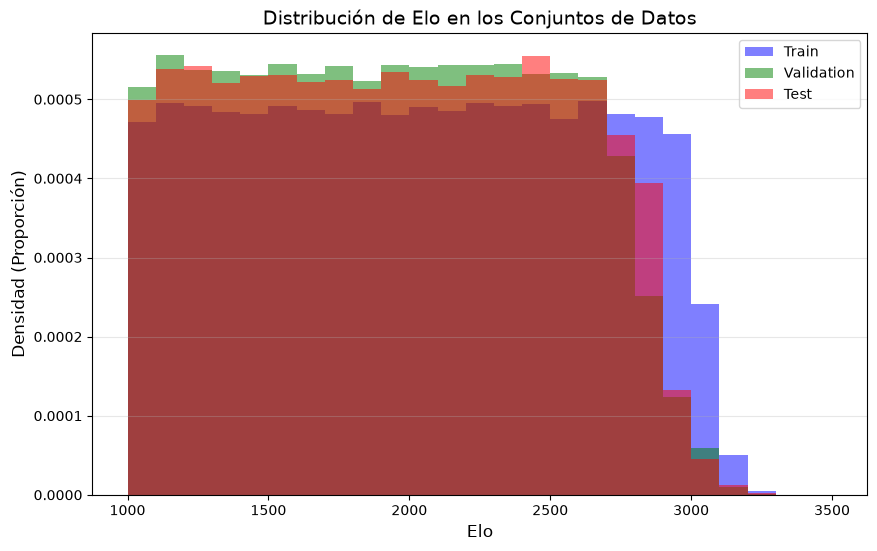

In [13]:
print("Generando histograma...")

plt.figure(figsize=(10, 6))

# Dibujamos los 3 histogramas. 
# alpha = transparencia para ver si se solapan.
# density = True es CLAVE para que los ejes Y representen proporciones y sean comparables.
bins_compartidos = np.arange(1000, 3600, 100) # Barras cada 50 puntos de Elo

plt.hist(train_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(val_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Validation', color='green')
plt.hist(test_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Test', color='red')

plt.title('Distribución de Elo en los Conjuntos de Datos', fontsize=14)
plt.xlabel('Elo', fontsize=12)
plt.ylabel('Densidad (Proporción)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Guarda la imagen en tu escritorio para usarla en la tesis
ruta_imagen = "../data/generado/graficos/distribucion_elo_data.png"
plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')
print(f"✅ Histograma guardado en: {ruta_imagen}")

plt.show()